**Normalisasi Data (Scaling)**

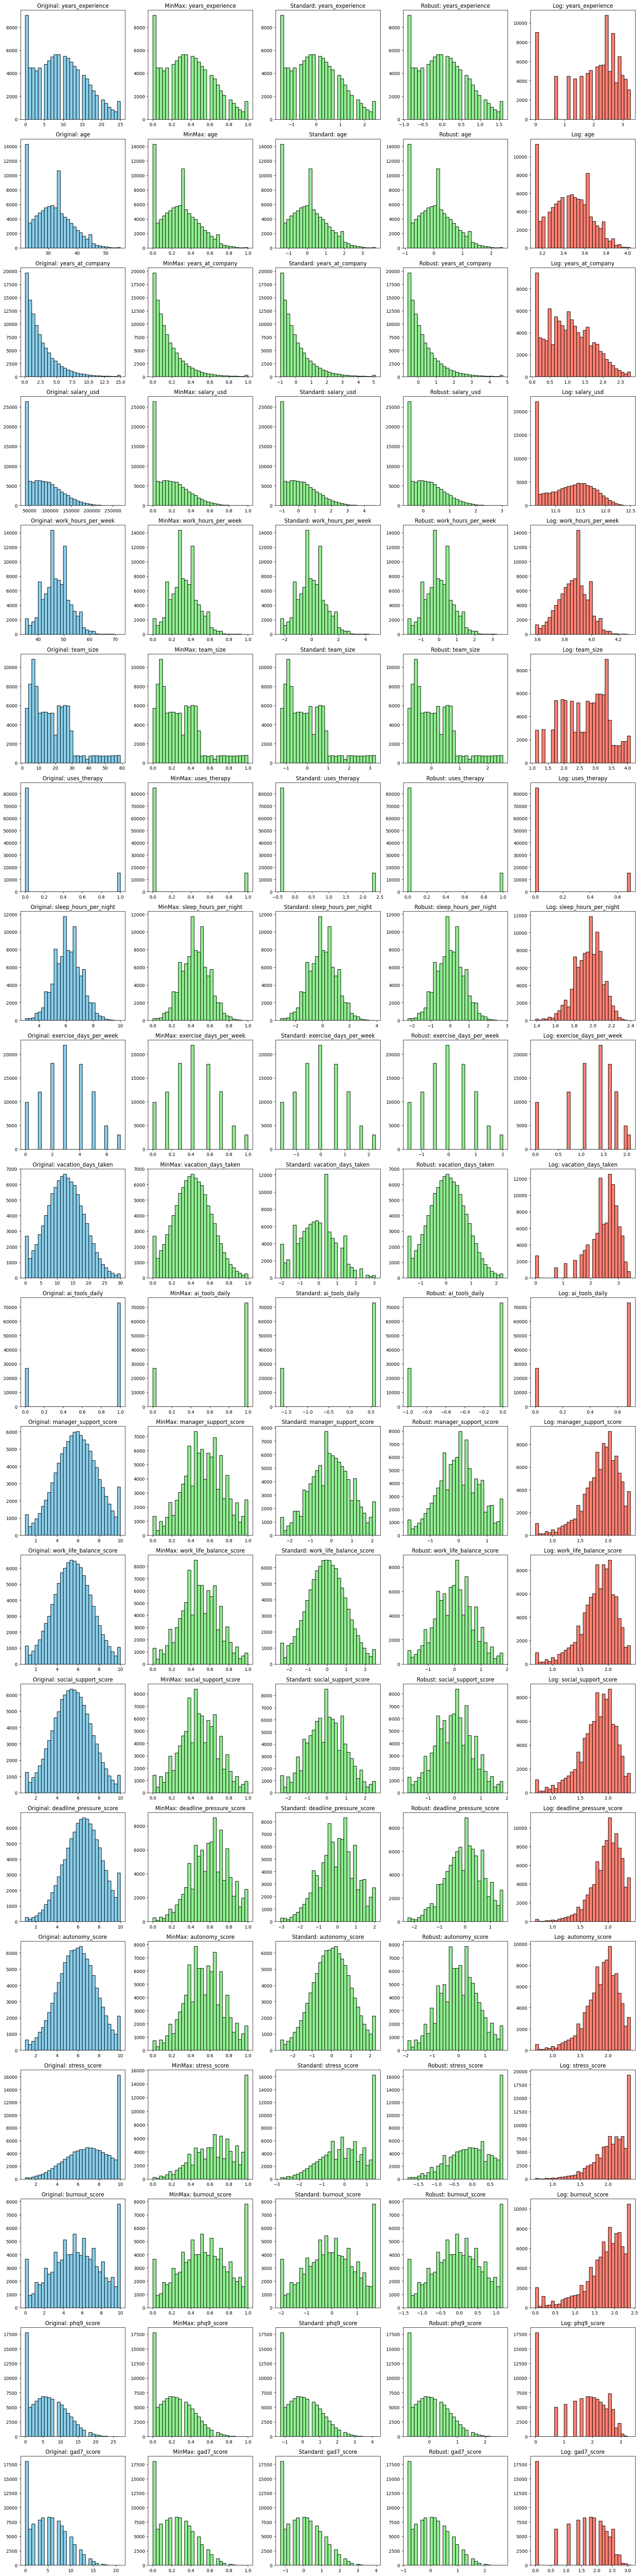

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

df = pd.read_csv('data_encoded.csv')

kolom_num = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Contoh menyertakan beberapa fitur yang mewakili Min-Max, Z-Score (Standard), dan Robust Scaling
kolom_uji = [
    'years_experience',        # Rencana: Min-Max Scaling
    'age',                     # Rencana: Z-Score Standardization
    'years_at_company',        # Rencana: Robust Scaling
    'salary_usd',              # Rencana: Z-Score Standardization
    'work_hours_per_week',     # Rencana: Min-Max Scaling
    'team_size',               # Rencana: Robust Scaling
    'uses_therapy',            # Rencana: Robust Scaling
    'sleep_hours_per_night',   # Rencana: Min-Max Scaling
    'exercise_days_per_week',  # Rencana: Min-Max Scaling
    'vacation_days_taken',     # Rencana: Min-Max Scaling
    'ai_tools_daily',          # Rencana: Min-Max Scaling
    'manager_support_score',   # Rencana: Min-Max Scaling
    'work_life_balance_score', # Rencana: Min-Max Scaling
    'social_support_score',    # Rencana: Min-Max Scaling
    'deadline_pressure_score', # Rencana: Z-Score Standardization
    'autonomy_score',          # Rencana: Min-Max Scaling
    'stress_score',            # Rencana: Min-Max Scaling
    'burnout_score',           # Rencana: Min-Max Scaling
    'phq9_score',              # Rencana: Z-Score Standardization
    'gad7_score'               # Rencana: Z-Score Standardization
]

scalers = {
    'MinMax':   MinMaxScaler(),
    'Standard': StandardScaler(),
    'Robust':   RobustScaler(),
}

# Membuat plot perbandingan
fig, axes = plt.subplots(len(kolom_uji), 5, figsize=(20, 4*len(kolom_uji)))

for i, kol in enumerate(kolom_uji):
    # Histogram Data Asli
    axes[i, 0].hist(df[kol], bins=30, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'Original: {kol}')

    # Histogram hasil berbagai Scaler
    for j, (nama, sc) in enumerate(scalers.items()):
        hasil = sc.fit_transform(df[[kol]]).flatten()
        axes[i, j+1].hist(hasil, bins=30, color='lightgreen', edgecolor='black')
        axes[i, j+1].set_title(f'{nama}: {kol}')

    # Histogram hasil Log Transformation
    axes[i, 4].hist(np.log1p(df[kol]), bins=30, color='salmon', edgecolor='black')
    axes[i, 4].set_title(f'Log: {kol}')

plt.tight_layout()
plt.savefig('LK_T3_perbandingan.png', dpi=100)
plt.show()
df.to_csv('data_scaled.csv', index=False)